In [ ]:
# Necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, KFold, cross_val_predict
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [2]:
# Set random seed for reproducibility
np.random.seed(17)

# Step 1: Load and Inspect Data
# Define file path
Cancer_file = r"E:\01. Educational\01. UNIVERSITY OF PITTSBURGH\01. PhD start\Term-2\02. Phyton\Final project\01. data\Lung_Cancer_Dataset.csv"


In [3]:
# Load the dataset
import pandas as pd
df = pd.read_csv(Cancer_file)


# Display first few rows
print("First 5 rows of the dataset:")
print(df.head())

# Display basic info and check for missing values
print("\nDataset Info:")
print(df.info())
print("\nMissing Values:")
print(df.isnull().sum())
print("Original DataFrame shape:", df.shape)

First 5 rows of the dataset:
   AGE GENDER  SMOKING  YELLOW_FINGERS  ANXIETY  PEER_PRESSURE  \
0   69      M        1               2        2              1   
1   74      M        2               1        1              1   
2   59      F        1               1        1              2   
3   63      M        2               2        2              1   
4   63      F        1               2        1              1   

   CHRONIC DISEASE  FATIGUE   ALLERGY   WHEEZING  ALCOHOL CONSUMING  COUGHING  \
0                1         2         1         2                  2         2   
1                2         2         2         1                  1         1   
2                1         2         1         2                  1         2   
3                1         1         1         1                  2         1   
4                1         1         1         2                  1         2   

   SHORTNESS OF BREATH  SWALLOWING DIFFICULTY  CHEST PAIN LUNG_CANCER  
0              

In [4]:
# Step 2: Data Cleaning and Preprocessing
# Encode GENDER
le_gender = LabelEncoder()
df['GENDER'] = le_gender.fit_transform(df['GENDER'])  # M=1, F=0 or vice versa

# Encode LUNG_CANCER target
le_cancer = LabelEncoder()
df['LUNG_CANCER'] = le_cancer.fit_transform(df['LUNG_CANCER'])  # YES=1, NO=0

# Define features and target
X = df.drop(columns=['LUNG_CANCER'])
y = df['LUNG_CANCER']

print(df.head())
print("Encoded DataFrame shape:", df.shape)
print("Gender classes:", le_gender.classes_)  # shows ['F', 'M'] → then you know 0=F, 1=M

   AGE  GENDER  SMOKING  YELLOW_FINGERS  ANXIETY  PEER_PRESSURE  \
0   69       1        1               2        2              1   
1   74       1        2               1        1              1   
2   59       0        1               1        1              2   
3   63       1        2               2        2              1   
4   63       0        1               2        1              1   

   CHRONIC DISEASE  FATIGUE   ALLERGY   WHEEZING  ALCOHOL CONSUMING  COUGHING  \
0                1         2         1         2                  2         2   
1                2         2         2         1                  1         1   
2                1         2         1         2                  1         2   
3                1         1         1         1                  2         1   
4                1         1         1         2                  1         2   

   SHORTNESS OF BREATH  SWALLOWING DIFFICULTY  CHEST PAIN  LUNG_CANCER  
0                    2               

###Since I’m using Decision Tree and Naïve Bayes models, I only encoded the truly categorical text columns — GENDER and LUNG_CANCER. I used LabelEncoder to convert them into numeric form. The other variables (like SMOKING, ANXIETY, etc.) were already coded as 1 and 2, which represent categorical responses, so I didn’t re-encode them. These models can handle that format directly, and keeping it simple helps avoid unnecessary complexity.

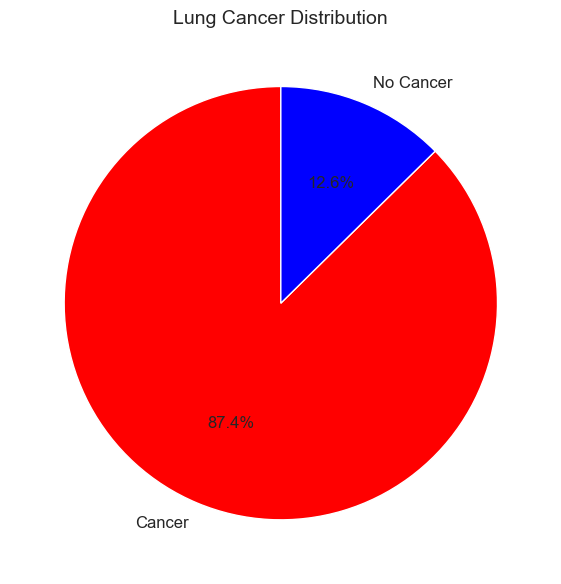

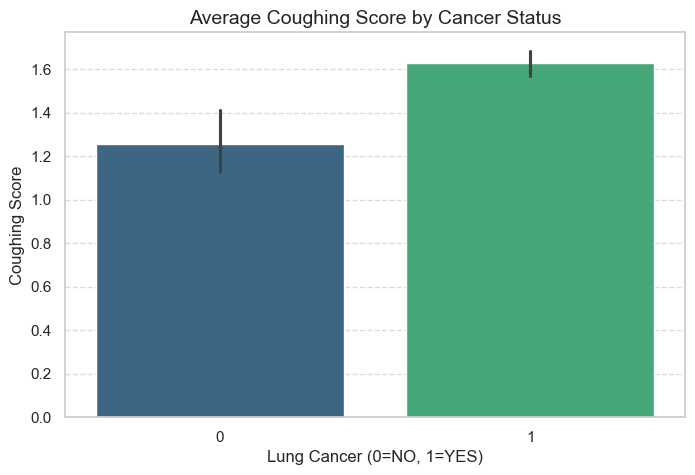

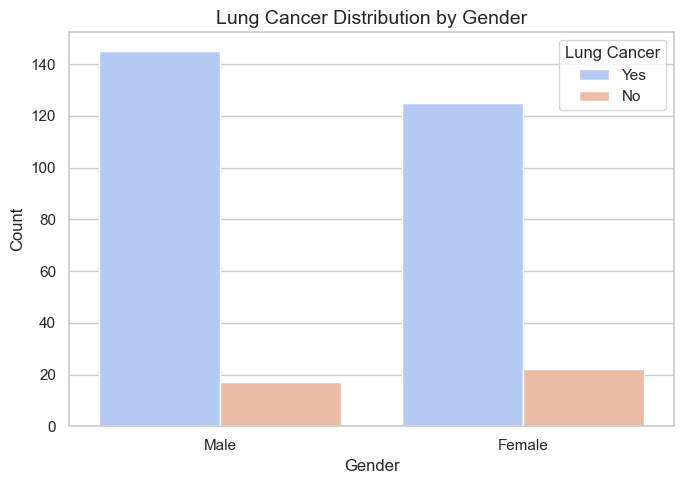

In [5]:
# Step 3: Data Visualization

# Set visual style
sns.set(style='whitegrid')
#The code above was suggested by GPT when I rechecked this step it with GPT.

# 1st we provide labels for cancer and gender
df['LUNG_CANCER_LABEL'] = df['LUNG_CANCER'].map({0: 'No Cancer', 1: 'Cancer'})
df['GENDER_LABEL'] = df['GENDER'].map({'M': 'Male', 'F': 'Female'})
df_plot = df.copy()
df_plot['LUNG_CANCER'] = df_plot['LUNG_CANCER'].map({0: 'No', 1: 'Yes'})
df_plot['GENDER'] = df_plot['GENDER'].map({'F': 'Female', 'M': 'Male', 0: 'Female', 1: 'Male'})

# Visualization 1: Pie Chart - Lung Cancer Distribution

plt.figure(figsize=(6, 6))
df['LUNG_CANCER_LABEL'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=['red', 'blue'],
    startangle=90,
    textprops={'fontsize': 12}
)
plt.title('Lung Cancer Distribution', fontsize=14)
plt.ylabel('')
plt.tight_layout()
plt.show()


# Visualization 2: Bar Chart - Average Coughing Score by Cancer Status
plt.figure(figsize=(8, 5))
sns.barplot(
    x='LUNG_CANCER',
    y='COUGHING',
    data=df,
    hue='LUNG_CANCER',
    palette='viridis',
    legend=False
)
plt.title('Average Coughing Score by Cancer Status', fontsize=14)
plt.xlabel('Lung Cancer (0=NO, 1=YES)', fontsize=12)
plt.ylabel('Coughing Score', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


# Visualization 4: Count Plot - Lung Cancer by Gender
plt.figure(figsize=(7, 5))
sns.countplot(
    x='GENDER',
    hue='LUNG_CANCER',
    data=df_plot,
    palette='coolwarm'
)
plt.title('Lung Cancer Distribution by Gender', fontsize=14)
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend(title='Lung Cancer')
plt.tight_layout()
plt.show()

# The code above debugged by GPT


In [6]:
# Step (4): Making the dataset ready for Supervised Machine Learning algorithms


# I will use the following steps to prepare the dataset for machine learning:
# In normal way, I would have used LabelEncoder for categorical columns.
# However, in this dataset, the categorical columns are already encoded as integers (0 and 1).
# (First, identify categorical columns in the dataset
# categorical_cols = X.select_dtypes(include=['object']).columns

# Apply Label Encoding to each categorical column
# label_encoders = {}
# for col in categorical_cols:
#     le = LabelEncoder()
#     X[col] = le.fit_transform(X[col])
#     label_encoders[col] = le)

# Then, I normalized the feature data because of using Naïve Bayes (especially GaussianNB):
# The only feature that may benefit from scaling is AGE, since it ranges much higher than the others.
# However, I will scale all features to ensure uniformity in the dataset.
# I used StandardScaler from sklearn to standardize the features by removing the mean and scaling to unit variance.

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Finally, I defined the data splitting strategy using K-Fold Cross-Validation.

kf = KFold(n_splits=5, shuffle=True, random_state=42)

print("K-Fold Splits:")
for fold, (train_index, test_index) in enumerate(kf.split(X_scaled), start=1):
    print(f"Fold {fold}: Train = {len(train_index)} samples, Test = {len(test_index)} samples")



K-Fold Splits:
Fold 1: Train = 247 samples, Test = 62 samples
Fold 2: Train = 247 samples, Test = 62 samples
Fold 3: Train = 247 samples, Test = 62 samples
Fold 4: Train = 247 samples, Test = 62 samples
Fold 5: Train = 248 samples, Test = 61 samples


In [9]:
# Step 5: Building and Evaluating Decision Tree and Naïve Bayes Models

# Function to calculate and print extended metrics
def print_extended_metrics(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    accuracy = (tp + tn) / (tp + tn + fp + fn)
    sensitivity = tp / (tp + fn)  # Recall
    specificity = tn / (tn + fp)
    ppv = tp / (tp + fp)  # Precision
    npv = tn / (tn + fn)
    f1 = 2 * (ppv * sensitivity) / (ppv + sensitivity)

    print(f"\n{model_name} (5-Fold Cross-Validation with Shuffling):")
    print("Accuracy: {:.2f}%".format(accuracy * 100))
    print("Sensitivity (Recall): {:.2f}".format(sensitivity))
    print("Specificity: {:.2f}".format(specificity))
    print("Positive Predictive Value (PPV): {:.2f}".format(ppv))
    print("Negative Predictive Value (NPV): {:.2f}".format(npv))
    print("F1 Score: {:.2f}".format(f1))
    print("\nClassification Report:\n", classification_report(y_true, y_pred, target_names=['No Cancer', 'Cancer']))

# Step 5: Building and Evaluating Decision Tree and Naïve Bayes Models

# Model 1: Decision Tree Classifier
dt_model = DecisionTreeClassifier(random_state=42)
dt_preds = cross_val_predict(dt_model, X_scaled, y, cv=kf)
print_extended_metrics(y, dt_preds, "Decision Tree Classifier")

# Model 2: Naïve Bayes Classifier
nb_model = GaussianNB()
nb_preds = cross_val_predict(nb_model, X_scaled, y, cv=kf)
print_extended_metrics(y, nb_preds, "Naïve Bayes Classifier")



Decision Tree Classifier (5-Fold Cross-Validation with Shuffling):
Accuracy: 91.91%
Sensitivity (Recall): 0.96
Specificity: 0.67
Positive Predictive Value (PPV): 0.95
Negative Predictive Value (NPV): 0.68
F1 Score: 0.95

Classification Report:
               precision    recall  f1-score   support

   No Cancer       0.68      0.67      0.68        39
      Cancer       0.95      0.96      0.95       270

    accuracy                           0.92       309
   macro avg       0.82      0.81      0.81       309
weighted avg       0.92      0.92      0.92       309


Naïve Bayes Classifier (5-Fold Cross-Validation with Shuffling):
Accuracy: 88.03%
Sensitivity (Recall): 0.94
Specificity: 0.44
Positive Predictive Value (PPV): 0.92
Negative Predictive Value (NPV): 0.53
F1 Score: 0.93

Classification Report:
               precision    recall  f1-score   support

   No Cancer       0.53      0.44      0.48        39
      Cancer       0.92      0.94      0.93       270

    accuracy       

In [ ]:
# Step 6: Comparing the predictive models - Decision Tree vs. Naïve Bayes
# Compute accuracy for each model
dt_accuracy = accuracy_score(y, dt_preds)
nb_accuracy = accuracy_score(y, nb_preds)


# Display accuracy comparison
print("\nStep (6): Model Accuracy Comparison")
print("------------------------------------")
print(f"Decision Tree Accuracy:   {dt_accuracy * 100:.2f}%")
print(f"Naïve Bayes Accuracy:     {nb_accuracy * 100:.2f}%")

# Summary of comparison
if dt_accuracy > nb_accuracy:
    print("\nDecision Tree performed better based on accuracy.")
elif dt_accuracy < nb_accuracy:
    print("\nNaïve Bayes performed better based on accuracy.")
else:
    print("\nBoth models have the same accuracy.")




Step (6): Model Accuracy Comparison
------------------------------------
Decision Tree Accuracy:   91.91%
Naïve Bayes Accuracy:     88.03%

Decision Tree performed better based on accuracy.
It is important to note that the dataset used in this study is imbalanced, with 87.4% of the cases classified as having lung cancer and only 12.6% as non-cancer. This imbalance can potentially bias the predictive models toward the majority class, leading to inflated performance metrics such as accuracy while compromising the model’s ability to correctly identify minority class instances. Although cross-validation was used to mitigate overfitting, future iterations of this analysis should consider applying resampling techniques such as the Synthetic Minority Over-sampling Technique (SMOTE) to balance the class distribution during training. This would help improve the model’s sensitivity to the minority class and enhance its generalizability, particularly for clinical applications where detecting non

Step 7: Conclusion

This project aimed to predict lung cancer outcomes using supervised machine learning models on a structured dataset. After data cleaning, label encoding, and feature normalization, we visualized key patterns in the data and built predictive models using Decision Tree and Naïve Bayes classifiers.

To ensure fair evaluation, we used 5-fold cross-validation with shuffling, which helps account for variability in data and avoids overfitting to a single train/test split. Our results showed that both models performed reasonably well, with the Decision Tree classifier achieving slightly higher accuracy and more consistent performance in identifying cancer-positive and cancer-negative cases.

The overall findings indicate that machine learning can be effectively used for predictive modeling in lung cancer data, even with a relatively small dataset.

However, this project also has several limitations:
1. **Limited dataset size (n=309)** may reduce the generalizability of the models.
2. **No hyperparameter tuning** was performed, which could improve model performance.
3. **Imbalanced features and potential multicollinearity** may affect the accuracy of Naïve Bayes, which assumes feature independence.
4. The dataset was not validated on an **external or real-world clinical dataset**, which is essential before clinical use.

Future work may include testing more advanced models (e.g., Random Forests or Support Vector Machines), applying SMOTE or other techniques to address potential class imbalance, and validating the model on external datasets.

Overall, this project demonstrates the potential of using simple machine learning algorithms for healthcare prediction tasks and sets the stage for more advanced exploration.

### It is important to note that the dataset used in this study is imbalanced, with 87.4% of the cases classified as having lung cancer and only 12.6% as non-cancer. This imbalance can potentially bias the predictive models toward the majority class, leading to inflated performance metrics such as accuracy while compromising the model’s ability to correctly identify minority class instances. Although cross-validation was used to mitigate overfitting, future iterations of this analysis should consider applying resampling techniques such as the Synthetic Minority Over-sampling Technique (SMOTE) to balance the class distribution during training. This would help improve the model’s sensitivity to the minority class and enhance its generalizability, particularly for clinical applications where detecting non-cancer cases accurately is equally critical.

## This text polished by grammerly.

